In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import os

import random
import shutil

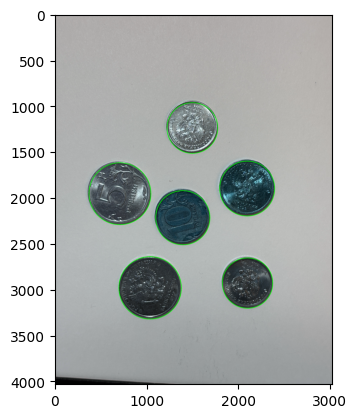

In [23]:
img_path = 'D:/practice 2nd year/Project/raw/scenes/IMG_3892.JPG'


# img_path = 'D:/practice 2nd year/Project/raw/singles/1/obverse/IMG_3814.JPG'



image = cv2.imread(img_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray, (9, 9), 2)

# Для нескольких
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=300,
    param1=150,
    param2=70,
    minRadius=150,
    maxRadius=400
)

#Для одной

# circles = cv2.HoughCircles(
#     gray,
#     cv2.HOUGH_GRADIENT,
#     dp=1,
#     minDist=1000,
#     param1=130,
#     param2=20,
#     minRadius=500,
#     maxRadius=800
# )

circles = np.uint16(np.around(circles))

img_circles = image.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))

    # Рисуем каждый найденный круг
    for i in circles[0, :]:
        # Рисуем окружность (контур круга)
        cv2.circle(img_circles, (i[0], i[1]), i[2], (0, 255, 0), 5)

        # Рисуем центр круга
        cv2.circle(img_circles, (i[0], i[1]), 2, (0, 0, 255), 1)

plt.imshow(img_circles)

In [14]:
def crop_coin(image, x, y, r, margin=15):
    """
    Вырезает монету, накладывает круглую маску и
    возвращает изображение только с монетой.
    """

    # Координаты квадрата
    x1 = max(0, x - r - margin)
    y1 = max(0, y - r - margin)

    x2 = min(image.shape[1], x + r + margin)
    y2 = min(image.shape[0], y + r + margin)

    # Вырезаем область
    crop = image[y1:y2, x1:x2]

    # Размер вырезанной области
    h, w = crop.shape[:2]

    # Создаем черную маску
    mask = np.zeros((h, w), dtype=np.uint8)

    # Центр монеты относительно вырезанного изображения
    center = (x - x1, y - y1)

    # Радиус маски
    radius = r

    # Рисуем белый круг
    cv2.circle(mask, center, radius, 255, -1)

    # Оставляем только монету
    result = cv2.bitwise_and(crop, crop, mask=mask)

    return result

1


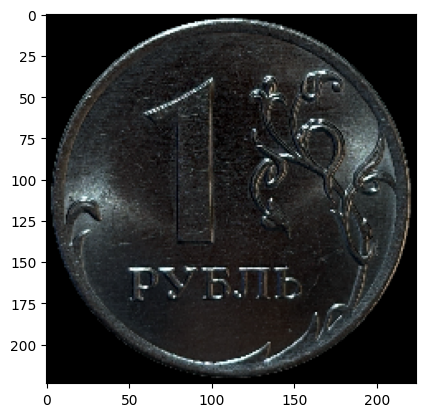

In [9]:
coins = []
for c in circles[0]:
    x, y, r = c

    coin = crop_coin(image, x, y, r)
    coin = cv2.resize(coin, (224, 224))
    plt.imshow(coin)
    coins.append(coin)
print(len(coins))

In [15]:
# Функция поиска одной монеты
def detect_coin(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (9, 9), 2)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=1000,
        param1=130,
        param2=20,
        minRadius=500,
        maxRadius=800
    )

    if circles is None:
        return None

    circles = np.uint16(np.around(circles))

    return circles[0][0]

In [11]:
# Пути

RAW_PATH = "raw/singles"
DATASET_PATH = "dataset"

TRAIN_RATIO = 0.8
IMG_SIZE = (224, 224)

random.seed(42)

# Создаем структуру dataset
for split in ["train", "val"]:
    for cls in ["1", "2", "5", "10"]:
        os.makedirs(
            os.path.join(DATASET_PATH, split, cls),
            exist_ok=True
        )



# Обработка каждого класса
# -----------------------------

for cls in ["1", "2", "5", "10"]:

    files = []

    class_folder = os.path.join(RAW_PATH, cls)

    # obverse + reverse
    for side in ["obverse", "reverse"]:

        side_folder = os.path.join(class_folder, side)

        if not os.path.exists(side_folder):
            continue

        for file in os.listdir(side_folder):

            if file.lower().endswith((".jpg", ".jpeg", ".png")):

                files.append(
                    os.path.join(side_folder, file)
                )

    # перемешиваем
    random.shuffle(files)

    split_index = int(len(files) * TRAIN_RATIO)

    train_files = files[:split_index]
    val_files = files[split_index:]

    for split_name, split_files in zip(
            ["train", "val"],
            [train_files, val_files]):

        counter = 1

        for file in split_files:

            image = cv2.imread(file)

            if image is None:
                continue

            circle = detect_coin(image)

            if circle is None:
                print("Монета не найдена:", file)
                continue

            x, y, r = circle

            coin = crop_coin(image, x, y, r)

            coin = cv2.resize(
                coin,
                IMG_SIZE
            )

            save_name = f"{cls}_{counter:03d}.jpg"

            save_path = os.path.join(
                DATASET_PATH,
                split_name,
                cls,
                save_name
            )

            cv2.imwrite(save_path, coin)

            counter += 1
print("Датасет успешно подготовлен.")

Датасет успешно подготовлен.


Формируем папку /all для тестировния метода k-fold

In [16]:
# -----------------------------
# Пути
# -----------------------------

RAW_PATH = "raw/singles"
DEST_PATH = "dataset/all"

IMG_SIZE = (224, 224)

CLASSES = ["1", "2", "5", "10"]

# -----------------------------
# Создание папок
# -----------------------------

for cls in CLASSES:
    os.makedirs(
        os.path.join(DEST_PATH, cls),
        exist_ok=True
    )

# -----------------------------
# Основной пайплайн
# -----------------------------

total_saved = 0

for cls in CLASSES:

    counter = 1

    class_path = os.path.join(RAW_PATH, cls)

    for side in ["obverse", "reverse"]:

        side_path = os.path.join(class_path, side)

        if not os.path.exists(side_path):
            continue

        for file in sorted(os.listdir(side_path)):

            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(side_path, file)

            image = cv2.imread(img_path)

            if image is None:
                print(f"Ошибка чтения: {img_path}")
                continue

            # -------------------------
            # 1. Детекция
            # -------------------------
            circle = detect_coin(image)

            if circle is None:
                print(f"⚠ Монета не найдена: {img_path}")
                continue

            x, y, r = circle

            # -------------------------
            # 2. Вырезание
            # -------------------------
            coin = crop_coin(image, x, y, r)

            if coin is None or coin.size == 0:
                print(f"⚠ Пустой crop: {img_path}")
                continue

            # -------------------------
            # 3. Resize под CNN
            # -------------------------
            coin = cv2.resize(coin, IMG_SIZE)

            # -------------------------
            # 4. Сохранение
            # -------------------------
            save_name = f"{cls}_{counter:04d}.jpg"

            save_path = os.path.join(
                DEST_PATH,
                cls,
                save_name
            )

            cv2.imwrite(save_path, coin)

            counter += 1
            total_saved += 1

print("\nГотово!")
print(f"Всего сохранено: {total_saved} изображений")


Готово!
Всего сохранено: 77 изображений
